# SQL in R and R Analytics

In [ ]:
# Install and load the datas
install.packages("sqldf")
install.packages("ggplot2")

library("sqldf")
library("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Loading all data
app_events <- read.csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/app_events_clean.csv")

complaints <- read.csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/complaints_clean.csv")

customers <- read.csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/customers_clean.csv")

deliveries <- read.csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/deliveries_clean.csv")

drivers <- read.csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/drivers_clean.csv")

hubs <- read.csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/hubs.csv")

incidents <- read.csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/incidents_clean.csv")

orders <- read.csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/orders_clean.csv")

vehicles <- read.csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/vehicles_clean.csv")

print("All files are loaded from github")

[1] "All files are loaded from github"


In [ ]:
head(deliveries)

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_hours
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>
1,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05,22.149973
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51,1.108991
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62,23.985584
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22,4.042814
5,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52.384869,Delayed,13.84,0,0,1.57,9.58,28.531218
6,DL00007,O00097,D151,V037,H07,2024-01-09 13:41:00,2024-01-10 23:39:11.072850,Delayed,32.72,0,0,4.64,17.70,33.969742


##### Delivery success analysis

In [ ]:
delivery_summary <- sqldf("
SELECT delivery_status,
       COUNT(*) AS total_deliveries
FROM deliveries
WHERE delivery_status IS NOT NULL
GROUP BY delivery_status
ORDER BY total_deliveries DESC
")

print(delivery_summary)

  delivery_status total_deliveries
1          OnTime              540
2         Delayed              198
3          Failed              129


##### Failed deliveries only

In [ ]:
failed_deliveries <- sqldf("
SELECT *
FROM deliveries
WHERE LOWER(delivery_status) = 'failed'
")

print(failed_deliveries)

    delivery_id order_id driver_id vehicle_id hub_id       dispatch_time
1       DL00001   O00938      D004       V056    H05 2024-06-18 10:57:00
2       DL00010   O00836      D058       V057    H08 2025-09-22 19:09:00
3       DL00012   O01207      D051       V017    H05 2024-12-26 19:41:00
4       DL00022   O01027      D088       V011    H07 2025-08-24 00:21:00
5       DL00026   O00906      D092       V055    H04 2025-02-04 11:16:00
6       DL00033   O00885      D041       V075    H06 2024-11-17 14:01:00
7       DL00038   O00727      D096       V002    H02 2025-10-26 15:31:00
8       DL00039   O00542      D090       V034    H08 2025-07-26 15:58:00
9       DL00040   O00919      D027       V036    H04 2025-02-01 08:38:00
10      DL00041   O00750      D100       V057    H08 2024-02-01 08:58:00
11      DL00057   O00921      D141       V077    H04 2024-12-09 10:53:00
12      DL00068   O00828      D104       V046    H08 2024-02-19 15:15:00
13      DL00069   O01039      D010       V074    H0

OPTIMISATION

In [ ]:
driver_performance <- sqldf("
SELECT driver_id,
       COUNT(*) AS total_trips,
       AVG(customer_rating_post_delivery) AS avg_rating
FROM deliveries
GROUP BY driver_id
HAVING total_trips > 5
ORDER BY avg_rating DESC
")

print(driver_performance)

   driver_id total_trips avg_rating
1       D039           7   4.552857
2       D015           6   4.521667
3       D108          10   4.353000
4       D036           7   4.344286
5       D164           7   4.342857
6       D125           7   4.335714
7       D030           7   4.312857
8       D142           8   4.288750
9       D054           6   4.276667
10      D110           7   4.251429
11      D093           6   4.220000
12      D105           7   4.205714
13      D155           7   4.197143
14      D045           8   4.156250
15      D010           7   4.145714
16      D046           6   4.125000
17      D067           6   4.120000
18      D001           6   4.096667
19      D166           6   4.091667
20      D121           6   4.088333
21      D026          11   4.079091
22      D102          10   4.059000
23      D082           6   4.021667
24      D135          10   4.000000
25      D089           7   3.990000
26      D037           6   3.973333
27      D018           6   3

##### DELIVERY STATUS SUMMARY

In [ ]:
delivery_status_summary <- sqldf("
SELECT delivery_status,
       COUNT(*) AS total,
       ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM deliveries), 2) AS percentage
FROM deliveries
GROUP BY delivery_status
ORDER BY total DESC
")

print(delivery_status_summary)

  delivery_status total percentage
1          OnTime   540      62.28
2         Delayed   198      22.84
3          Failed   129      14.88


##### TOP ZONE ANALYSIS


In [ ]:
zone_analysis <- sqldf("
SELECT o.pickup_zone,
       COUNT(*) AS failed_count
FROM deliveries d
JOIN orders o ON d.order_id = o.order_id
WHERE LOWER(d.delivery_status) = 'failed'
GROUP BY o.pickup_zone
ORDER BY failed_count DESC
LIMIT 5
")

print(zone_analysis)

  pickup_zone failed_count
1       North           22
2     Central           21
3        East           19
4   Riverside           18
5        West           14


##### OPTIMISED COST ANALYSIS

In [ ]:
cost_efficiency <- sqldf("
SELECT hub_id,
       AVG(fuel_or_charge_cost) AS avg_cost,
       COUNT(*) AS total_trips
FROM deliveries
WHERE fuel_or_charge_cost IS NOT NULL
GROUP BY hub_id
HAVING total_trips > 10
ORDER BY avg_cost DESC
")

print(cost_efficiency)

  hub_id avg_cost total_trips
1    H05 13.68111         108
2    H06 13.34726          95
3    H04 13.22440         116
4    H07 13.08407         108
5    H01 12.91958         118
6    H03 12.67168         107
7    H02 12.52835          97
8    H08 11.63119         118


##### INTERPRETATION

In [ ]:
kpi_analysis <- sqldf("
SELECT
    COUNT(*) AS total_deliveries,
    SUM(CASE WHEN LOWER(delivery_status) = 'failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    ROUND(
        SUM(CASE WHEN LOWER(delivery_status) = 'failed' THEN 1 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS failure_rate
FROM deliveries
")

print(kpi_analysis)

  total_deliveries failed_deliveries failure_rate
1              867               129        14.88


In [ ]:
complaint_analysis <- sqldf("
SELECT complaint_type,
       COUNT(*) AS total_complaints,
       AVG(compensation_amount) AS avg_compensation
FROM complaints
GROUP BY complaint_type
ORDER BY total_complaints DESC
")
print(complaint_analysis)

     complaint_type total_complaints avg_compensation
1             Delay              101         18.07599
2      MissedPickup               64         22.52820
3          AppIssue               53         19.54594
4   DriverBehaviour               51         20.88402
5 SupportExperience               20         17.12500
6           Billing               16         23.87125
7            Damage               15         23.98200


##### TOP DRIVERS WITH FAILED DELIVERIES

In [ ]:
top_failed_drivers <- sqldf("
SELECT d.driver_id,
       dr.employment_type,
       dr.driver_rating,
       COUNT(*) AS failed_deliveries
FROM deliveries d
JOIN drivers dr ON d.driver_id = dr.driver_id
WHERE LOWER(d.delivery_status) = 'failed'
GROUP BY d.driver_id, dr.employment_type, dr.driver_rating
ORDER BY failed_deliveries DESC
LIMIT 10
")

print(top_failed_drivers)

   driver_id employment_type driver_rating failed_deliveries
1       D024        PartTime          3.35                 4
2       D104        FullTime          3.45                 4
3       D133        Contract          3.99                 4
4       D004        PartTime          4.75                 3
5       D010        FullTime          3.95                 3
6       D055        FullTime          5.00                 3
7       D083        FullTime          4.16                 3
8       D092        FullTime          4.24                 3
9       D108        FullTime          4.33                 3
10      D131        FullTime          4.26                 3


##### VEHICLE MAINTENANCE VS FAILURE RATE

In [ ]:
vehicle_failure_analysis <- sqldf("
SELECT v.maintenance_status,
       COUNT(*) AS total_deliveries,
       SUM(CASE WHEN LOWER(d.delivery_status) = 'failed' THEN 1 ELSE 0 END) AS failed,
       ROUND(SUM(CASE WHEN LOWER(d.delivery_status) = 'failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS failure_rate_pct
FROM deliveries d
JOIN vehicles v ON d.vehicle_id = v.vehicle_id
GROUP BY v.maintenance_status
ORDER BY failure_rate_pct DESC
")

print(vehicle_failure_analysis)

  maintenance_status total_deliveries failed failure_rate_pct
1           InRepair              236     74            31.36
2             Active              495     45             9.09
3          Scheduled              136     10             7.35


##### DELIVERY STATUS DISTRIBUTION

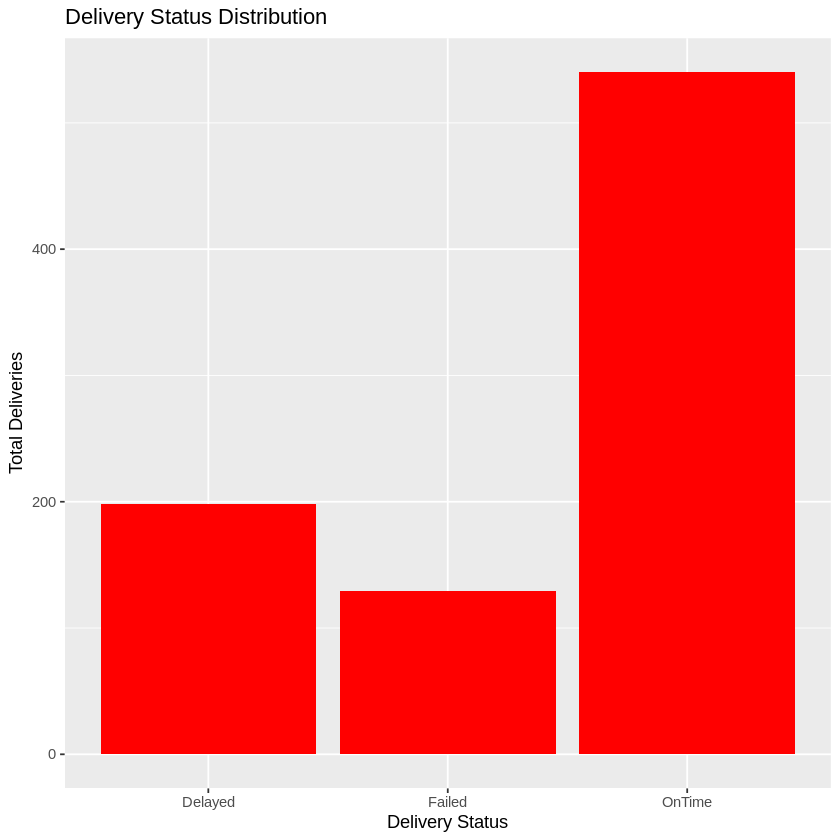

In [ ]:
delivery_summary <- sqldf("
SELECT delivery_status,
       COUNT(*) AS total_deliveries
FROM deliveries
WHERE delivery_status IS NOT NULL
GROUP BY delivery_status
")

ggplot(delivery_summary, aes(x = delivery_status, y = total_deliveries)) +
  geom_bar(stat = "identity", fill = "red") + # Added fill and color here
  labs(title = "Delivery Status Distribution",
       x = "Delivery Status",
       y = "Total Deliveries")

##### FAILED DELIVERIES BY ZONE

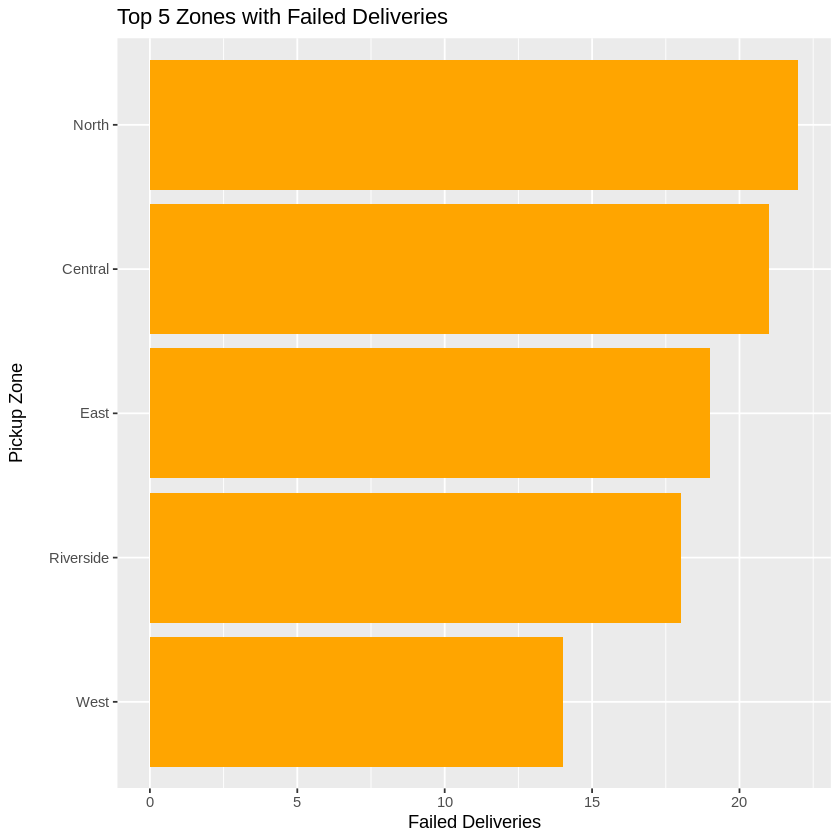

In [ ]:
failed_zones <- sqldf("
SELECT o.pickup_zone,
       COUNT(*) AS failed_count
FROM deliveries d
JOIN orders o ON d.order_id = o.order_id
WHERE LOWER(d.delivery_status) = 'failed'
GROUP BY o.pickup_zone
ORDER BY failed_count DESC
LIMIT 5
")

ggplot(failed_zones, aes(x = reorder(pickup_zone, failed_count), y = failed_count)) +
  geom_bar(stat = "identity", fill = "orange") + # Added fill and color here
  coord_flip() +
  labs(title = "Top 5 Zones with Failed Deliveries",
       x = "Pickup Zone",
       y = "Failed Deliveries")

##### COST EFFICIENCY BY HUB

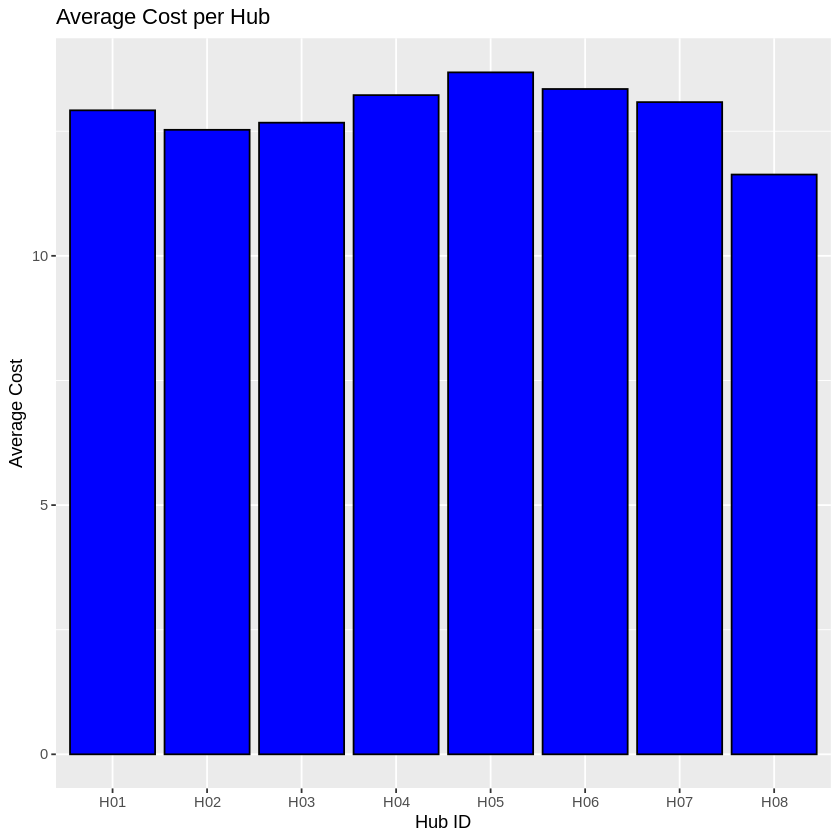

In [ ]:
cost_analysis <- sqldf("
SELECT hub_id,
       AVG(fuel_or_charge_cost) AS avg_cost
FROM deliveries
WHERE fuel_or_charge_cost IS NOT NULL
GROUP BY hub_id
")

ggplot(cost_analysis, aes(x = hub_id, y = avg_cost)) +
  geom_bar(stat = "identity", fill = "blue", color = "black") + # Added fill and color here
  labs(title = "Average Cost per Hub", x = "Hub ID", y = "Average Cost")

##### FAILURE RATE OVERALL

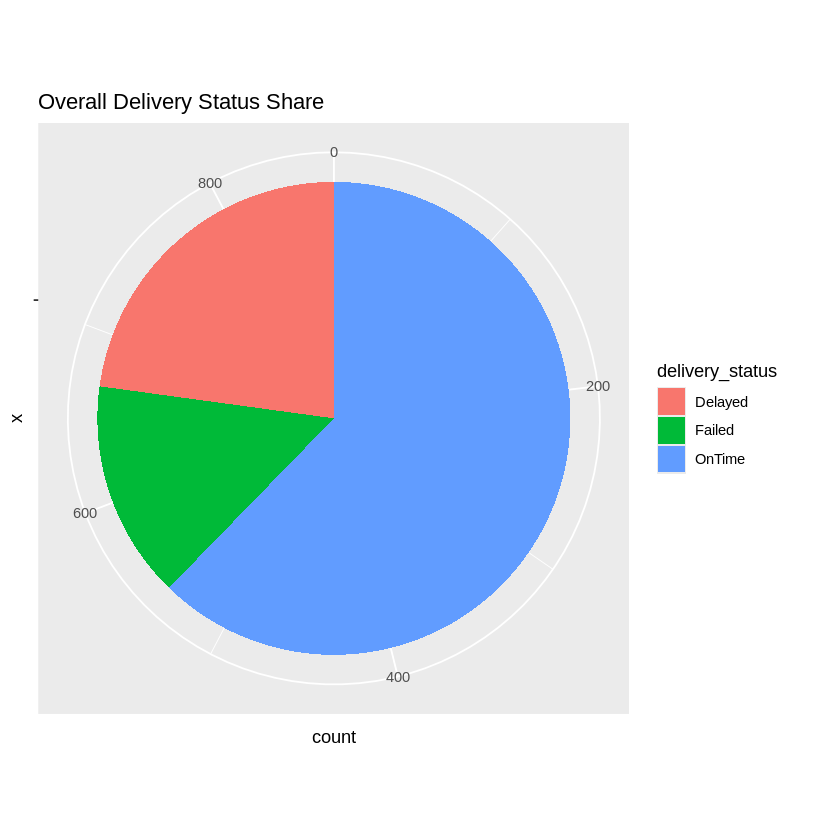

In [ ]:
kpi <- sqldf("
SELECT delivery_status,
       COUNT(*) AS count
FROM deliveries
GROUP BY delivery_status
")

ggplot(kpi, aes(x = "", y = count, fill = delivery_status)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y") +
  labs(title = "Overall Delivery Status Share")

# R Analytics

In [ ]:
install.packages("dplyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(dplyr)

##### FULL ANALYTICS FLOW

In [ ]:
library(dplyr)
deliveries %>%
  filter(!is.na(delivery_status)) %>%
  group_by(delivery_status) %>%
  summarise(total = n()) %>%
  arrange(desc(total))

delivery_status,total
<chr>,<int>
OnTime,540
Delayed,198
Failed,129


##### CLEANING + SUMMARIZING DELIVERY

In [ ]:
delivery_clean <- deliveries %>%
  filter(!is.na(delivery_status)) %>%
  group_by(delivery_status) %>%
  summarise(total = n()) %>%
  arrange(desc(total))

print(delivery_clean)

# A tibble: 3 × 2
  delivery_status total
  <chr>           <int>
1 OnTime            540
2 Delayed           198
3 Failed            129


##### FAILURE RATE (BASIC KPI)

In [ ]:
stats <- deliveries %>%
  summarise(
    total_deliveries = n(),
    failed = sum(delivery_status == "failed", na.rm = TRUE),
    failure_rate = round((failed / total_deliveries) * 100, 2)
  )

print(stats)

  total_deliveries failed failure_rate
1              867      0            0


##### DRIVER PERFORMANCE ANALYSIS

In [ ]:
driver_stats <- deliveries %>%
  group_by(driver_id) %>%
  summarise(
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    total_trips = n()
  ) %>%
  filter(total_trips > 5) %>%
  arrange(desc(avg_rating))

print(driver_stats)

# A tibble: 70 × 3
   driver_id avg_rating total_trips
   <chr>          <dbl>       <int>
 1 D039            4.55           7
 2 D015            4.52           6
 3 D108            4.35          10
 4 D036            4.34           7
 5 D164            4.34           7
 6 D125            4.34           7
 7 D030            4.31           7
 8 D142            4.29           8
 9 D054            4.28           6
10 D110            4.25           7
# ℹ 60 more rows


##### SORTING / OPTIMISATION

In [ ]:
deliveries %>%
  group_by(hub_id) %>%
  summarise(avg_cost = mean(fuel_or_charge_cost)) %>%
  arrange(desc(avg_cost))

hub_id,avg_cost
<chr>,<dbl>
H05,13.68111
H06,13.34726
H04,13.22440
H07,13.08407
H01,12.91958
H03,12.67168
H02,12.52835
H08,11.63119


##### STATISTICAL ANALYSIS

In [ ]:
deliveries %>%
  summarise(
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    failure_rate = mean(delivery_status == "failed") * 100
  )

avg_rating,failure_rate
<dbl>,<dbl>
3.848235,0


##### CORRELATION BETWEEN KEY NUMERIC VARIABLES

In [ ]:
cor_data <- deliveries[, c("fuel_or_charge_cost",
                            "manual_route_override_count",
                            "customer_rating_post_delivery")]

cor_matrix <- cor(cor_data, use = "complete.obs")
print(round(cor_matrix, 3))

                              fuel_or_charge_cost manual_route_override_count
fuel_or_charge_cost                         1.000                       0.099
manual_route_override_count                 0.099                       1.000
customer_rating_post_delivery              -0.070                      -0.057
                              customer_rating_post_delivery
fuel_or_charge_cost                                  -0.070
manual_route_override_count                          -0.057
customer_rating_post_delivery                         1.000


##### CONDITIONAL ANALYSIS

In [ ]:
deliveries <- deliveries %>%
  mutate(status_flag = ifelse(delivery_status == "failed", 1, 0))

print(head(deliveries$status_flag))

[1] 0 0 0 0 0 0


##### DELIVERY STATUS DISTRIBUTION

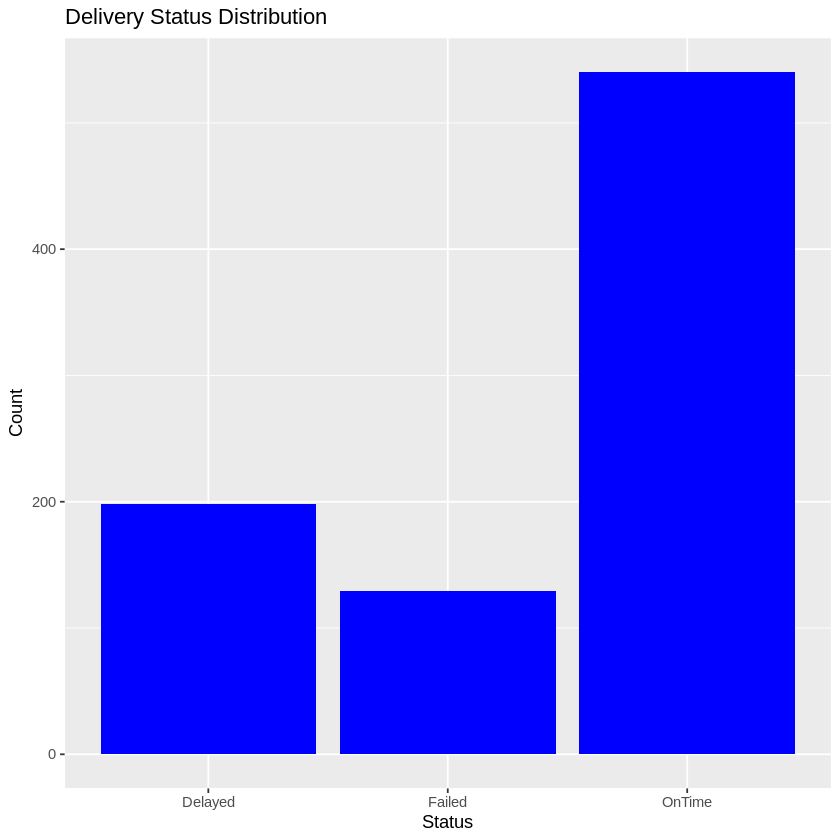

In [ ]:
status_data <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(total = n())

ggplot(status_data, aes(x = delivery_status, y = total)) +
  geom_bar(stat = "identity", fill = "blue") +
  labs(title = "Delivery Status Distribution",
       x = "Status",
       y = "Count")

##### COST ANALYSIS BY HUB

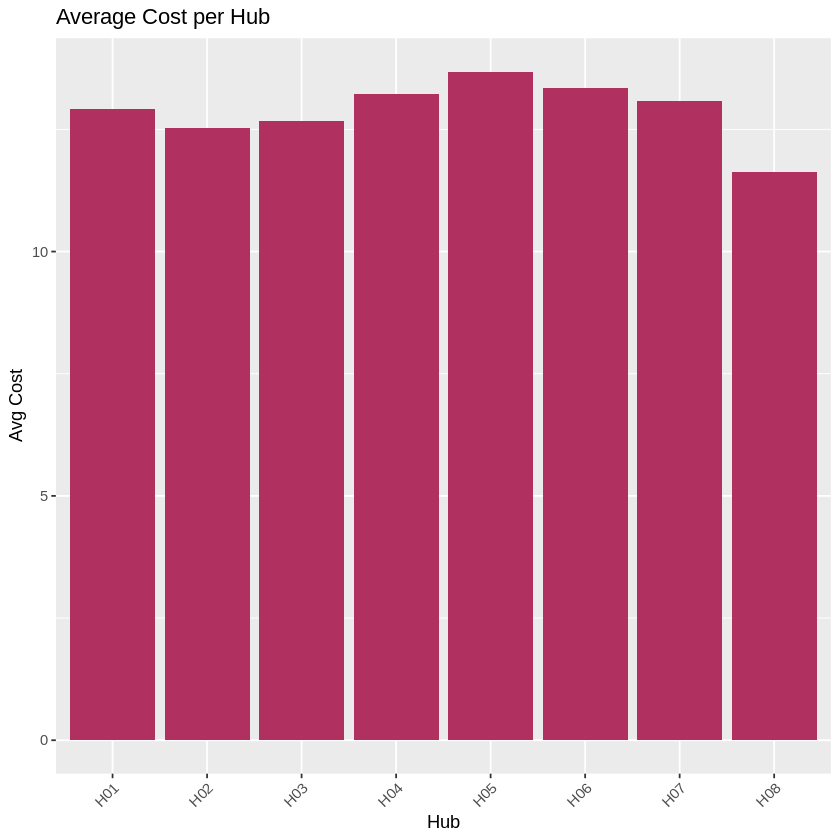

In [ ]:
cost_data <- deliveries %>%
  group_by(hub_id) %>%
  summarise(avg_cost = mean(fuel_or_charge_cost, na.rm = TRUE))

ggplot(cost_data, aes(x = hub_id, y = avg_cost)) +
  geom_bar(stat = "identity", fill = "maroon") +
  labs(title = "Average Cost per Hub",
       x = "Hub",
       y = "Avg Cost") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

##### Driver rating distribution


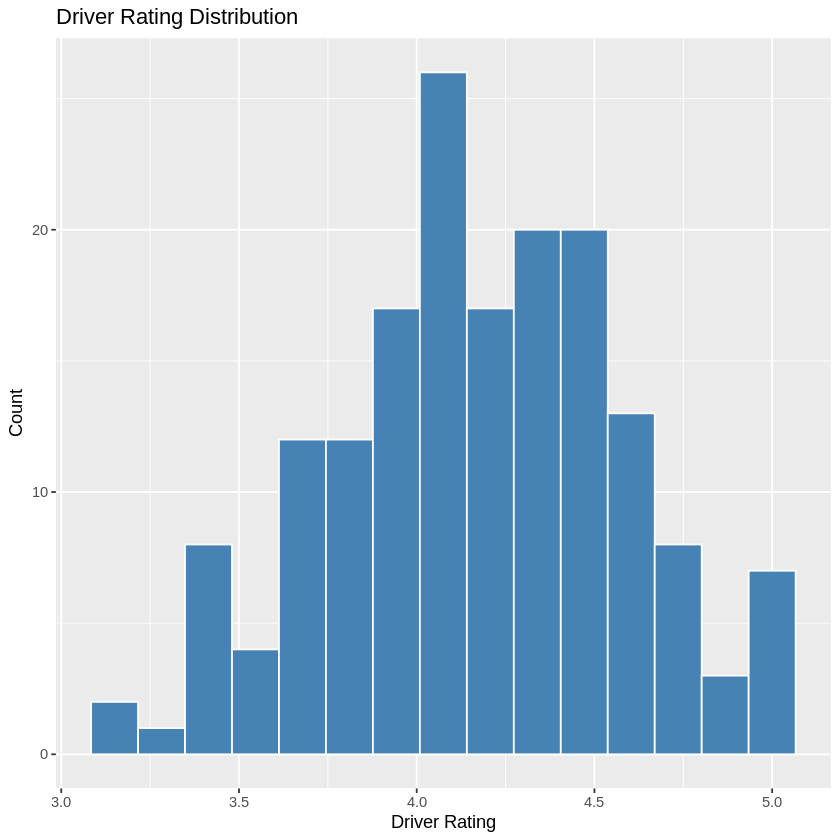

In [ ]:
ggplot(drivers, aes(x = driver_rating)) +
  geom_histogram(bins = 15, fill = "steelblue", color = "white") +
  labs(title = "Driver Rating Distribution",
       x = "Driver Rating",
       y = "Count")

# **Interpretation**

#### This notebook answers business questions using two analytical approaches: SQL queries inside R using `sqldf`, and native R analytics using `dplyr` and `ggplot2`.

### **SQL - Delivery Status Summary**

#### This query counted deliveries by status and ranked them. It provides the most fundamental operational KPI by showing how many deliveries were completed, failed, or delayed.

### **SQL - Failed Deliveries Filter**

#### This query isolated all failed delivery records for direct inspection. It serves as the starting point for root-cause analysis and operational investigation.

### **SQL - Driver Performance (HAVING)**

#### Drivers were ranked by average customer rating, restricted to those with more than 5 completed trips.

#### The `HAVING` clause ensured statistical reliability by excluding drivers with very few trips that could produce misleading ratings.

### **SQL - Status Percentage Breakdown**

#### This query calculated delivery statuses as both raw counts and percentages of total deliveries using a subquery.

#### Percentages provide more meaningful operational insight because they show relative scale rather than only absolute totals.

### **SQL - Top Zones with Failed Deliveries (JOIN)**

#### Deliveries were joined with orders to include `pickup_zone`, then failed deliveries were grouped by zone.

#### The top five failure zones identified operational hotspots requiring targeted intervention.

### **SQL - Cost Efficiency by Hub (HAVING)**

#### Hubs were ranked by average fuel or charge cost, restricted to hubs with more than 10 trips.

#### This analysis identified the most and least cost-efficient hubs, supporting resource allocation and optimisation decisions.

### **SQL - Overall KPI: Failure Rate**

#### This query calculated total deliveries, total failures, and the overall failure rate percentage in a single output.

#### The failure rate acts as the headline KPI for evaluating operational performance.

### **SQL - Complaint Analysis**

#### Complaints were grouped by complaint type to calculate both complaint frequency and average compensation cost.

#### This analysis identified which complaint categories were most common and financially costly.

### **SQL - Top Drivers with Failed Deliveries (JOIN)**

#### Failed deliveries were linked to driver records to identify drivers associated with the highest number of failures.

#### Driver employment type and rating were included to support retraining, reassignment, or performance management decisions.

### **SQL - Vehicle Maintenance vs Failure Rate (JOIN)**

#### Failure rates were calculated by vehicle maintenance status.

#### A higher failure rate among poorly maintained vehicles provides evidence that maintenance quality directly affects operational outcomes.

### **ggplot2 - Delivery Status Distribution**

#### A bar chart was created to visually compare completed, failed, and delayed deliveries.

#### This chart provides a quick visual summary of overall operational performance.

### **ggplot2 - Failed Deliveries by Zone**

#### A horizontal bar chart displayed the top zones with failed deliveries.

#### `coord_flip()` was used to improve readability of zone names.

### **ggplot2 - Average Cost per Hub**

#### This chart compared average delivery costs across hubs.

#### Hubs with significantly higher costs may require route optimisation or vehicle efficiency improvements.

### **ggplot2 - Overall Delivery Status Share (Pie Chart)**

#### A pie chart showed the proportional share of completed, failed, and delayed deliveries.

#### This complements the bar chart by emphasising relative proportions rather than raw counts.

### **dplyr - Delivery Summary, KPI, and Driver Performance**

#### The `dplyr` pipeline replicated the SQL analyses using native R syntax.

#### Consistent results between SQL and `dplyr` confirmed data integrity and validated the analysis methodology.

### **Correlation Matrix**

#### `cor()` was applied to fuel cost, manual route overrides, and customer rating to generate a numeric correlation matrix.

#### This provides the same analytical insight as the Python heatmap but in exact numerical form.

### **mutate - Status Flag**

#### A binary column named `status_flag` was created where `1 = failed` and `0 = not failed`.

#### This prepares the dataset for potential regression modelling or machine learning analysis in future work.

### **ggplot2 - Driver Rating Distribution**

#### A histogram visualised the distribution of driver ratings.

#### Ratings clustered at higher values indicate a generally strong driver workforce, while lower-value outliers may indicate underperforming drivers.

# **Overall Conclusion**

#### SQL and `dplyr` produced consistent analytical results, validating both the dataset and the analysis logic. The relationship between vehicle maintenance and delivery failure rates is particularly significant because it provides quantitative evidence that maintenance standards directly affect delivery success and operational reliability.